# Notebook 9 – Outlier Detection

## What are Outliers?

**Definition**

Outliers are data points that are significantly different from the other observations in a dataset.

**Example**

Consider the following ages:

18, 19, 20, 21, 22, 23, 65

Here, 65 is an outlier because it is much larger than the other values.

**Why Do We Use Outlier Detection?**

We detect outliers to:

- Find unusual observations
- Identify possible data-entry errors
- Improve data quality
- Understand unusual behavior
- Prevent extreme values from unnecessarily affecting statistical analysis or machine-learning models

*`Important:` An outlier is not always an error. It may represent a genuine and important observation.*

## Types of Outliers

There are three commonly discussed types of outliers.

### 1. Point Outlier

A single observation is significantly different from the rest of the data.

**Example:**

10, 11, 12, 13, 100

Here, 100 is a point outlier.

### 2. Contextual Outlier

A value is unusual in a particular context, but may not be unusual in another context.

**Example:**

A temperature of 35°C may be normal in summer but unusual in a particular winter context.

### 3. Collective Outlier

A group of observations behaves unusually when considered together.

**Example:**

In network monitoring, a sequence of unusual login attempts occurring together may indicate abnormal activity even if each individual attempt does not look extreme by itself.

## Detecting Outliers

There are several methods for detecting outliers.

**Common methods include:**

- IQR Method
- Z-Score Method
- Box Plot
- Scatter Plot

The appropriate method depends on the type and distribution of the data.

## IQR Method

**Definition**

The Interquartile Range (IQR) method identifies outliers using the first quartile (Q1) and third quartile (Q3).

**Formula**

$$ IQR = Q3 - Q1 $$

The lower and upper boundaries are:

$$ Lower\ Bound = Q1 - 1.5(IQR) $$ $$ Upper\ Bound = Q3 + 1.5(IQR) $$

Any value below the lower bound or above the upper bound is considered an outlier by this rule.

**Example**

Data = [10, 12, 13, 14, 15, 16, 18, 100]

100 is likely to be detected as an outlier.

In [1]:
import numpy as np

data = np.array([10, 12, 13, 14, 15, 16, 18, 100])

Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data < lower_bound) | (data > upper_bound)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Outliers:", outliers)

Q1: 12.75
Q3: 16.5
IQR: 3.75
Lower Bound: 7.125
Upper Bound: 22.125
Outliers: [100]


#### Why Do We Use IQR?

IQR is useful for detecting outliers without being strongly affected by extreme values and is commonly useful for skewed data.

## Z-Score Method

**Definition**

A Z-score tells us how many standard deviations a data point is away from the mean.

**Formula**

$$ z = \frac{x-\mu}{\sigma} $$

Where:

x = Data point

μ = Mean

σ = Standard deviation

A common rule is:

$$ |z| > 3 $$

may be considered an outlier, although the appropriate threshold depends on the application and assumptions about the data.

In [3]:
from scipy.stats import zscore
import numpy as np

data = np.array([10, 12, 13, 14, 15, 16, 18, 100])

z_scores = zscore(data)

outliers = data[np.abs(z_scores) > 3]

print("Z-Scores:", z_scores)
print("Outliers:", outliers)

Z-Scores: [-0.5169277  -0.44683581 -0.41178986 -0.37674392 -0.34169797 -0.30665203
 -0.23656013  2.63720742]
Outliers: []


**Why Do We Use It?**

The Z-score method is useful for identifying observations that are far from the mean in terms of standard deviations, particularly when the data is approximately normally distributed.

## Box Plot

**Definition**

A `Box Plot` is a graphical method for displaying the distribution of numerical data and identifying potential outliers.

A box plot shows:

- Minimum
- Q1
- Median
- Q3
- Maximum
- Potential outliers


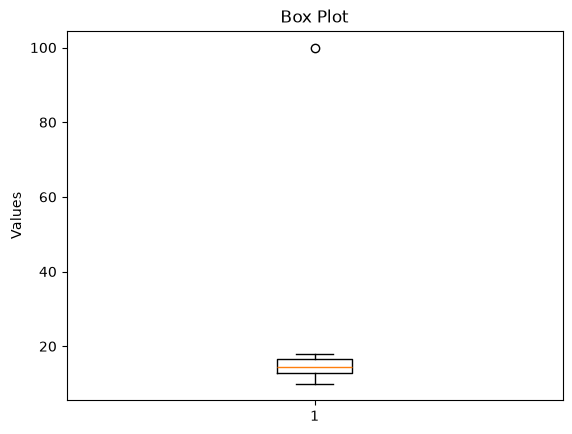

In [5]:
import matplotlib.pyplot as plt

data = [10, 12, 13, 14, 15, 16, 18, 100]

plt.boxplot(data)
plt.title("Box Plot")
plt.ylabel("Values")
plt.show()

**How to Identify Outliers?**

In a standard box plot, observations beyond the whiskers are typically displayed as individual points and are treated as potential outliers under the 1.5 × IQR rule.

**Why Do We Use It?**

Box plots are useful when we want to quickly visualize the distribution and potential outliers in numerical data.

## Scatter Plot

**Definition**

A Scatter Plot displays individual data points using two numerical variables.

It can help identify unusual observations that are far away from the general pattern of the data.

**Example**

Suppose we have:

Hours Studied

Exam Marks

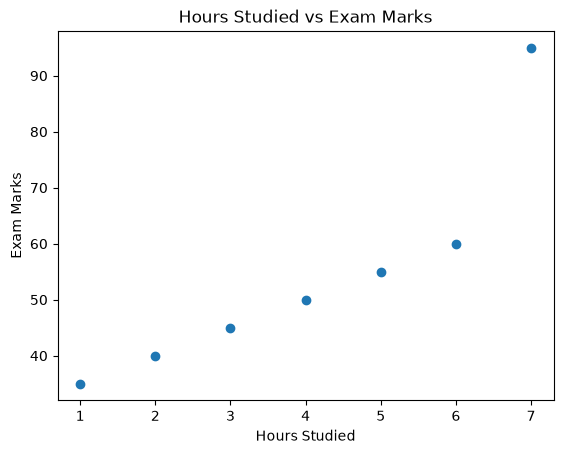

In [6]:
import matplotlib.pyplot as plt

hours = [1, 2, 3, 4, 5, 6, 7]
marks = [35, 40, 45, 50, 55, 60, 95]

plt.scatter(hours, marks)
plt.xlabel("Hours Studied")
plt.ylabel("Exam Marks")
plt.title("Hours Studied vs Exam Marks")
plt.show()

If one point is far away from the general pattern, it may be a potential outlier.

**Why Do We Use It?**

Scatter plots are useful for detecting unusual observations and patterns between two numerical variables.

**QR vs Z-Score**

| IQR Method                      | Z-Score Method                                             |   |      |
| ------------------------------- | ---------------------------------------------------------- | - | ---- |
| Uses quartiles                  | Uses mean and standard deviation                           |   |      |
| Less affected by extreme values | Can be affected by extreme values                          |   |      |
| Useful for skewed data          | Works well when data is approximately normally distributed |   |      |
| Uses 1.5 × IQR rule             | Commonly uses `                                            | z | > 3` |
| Easy to interpret               | Measures distance from the mean                            |   |      |


**Box Plot vs Scatter Plot**

| Box Plot                                        | Scatter Plot                                       |
| ----------------------------------------------- | -------------------------------------------------- |
| Shows distribution of one numerical variable    | Shows relationship between two numerical variables |
| Uses quartiles and median                       | Uses individual X-Y points                         |
| Good for spotting outliers in a single variable | Good for spotting unusual points in relationships  |
| Useful for comparing distributions              | Useful for analyzing patterns between variables    |


**Summary:**

| Topic                  | Why Do We Use It?                                                   |
| ---------------------- | ------------------------------------------------------------------- |
| **Outliers**           | To identify unusually different observations                        |
| **Types of Outliers**  | To understand different kinds of unusual observations               |
| **Detecting Outliers** | To find potential unusual values in a dataset                       |
| **IQR Method**         | To detect outliers using quartiles                                  |
| **Z-Score Method**     | To detect values far from the mean                                  |
| **Box Plot**           | To visually identify potential outliers and understand distribution |
| **Scatter Plot**       | To identify unusual points in relationships between two variables   |
